### Berm Condition & Vegetation — RF Model Approaches

Feature selection and random-forest model comparisons for condition and vegetation response outcomes.

Loads `../data/merged.csv` produced by `data processing - condition vegetation.ipynb`.



In [1]:
import sys as _sys
_sys.path.insert(0, '../src')
from constants import (
    INTACT_COL, DEGRADED_COL,
    eff_colors,
    LBL_EFFECTIVE,
    MODEL_CLR_CONDITION, MODEL_CLR_VEGRESPONSE, MODEL_CLR_CHANCE,
    FS, FS_SUP,
)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module=r'seaborn(\..*)?')
from IPython.display import display
pd.set_option('display.max_columns', 50)

In [2]:
data = pd.read_csv('../data/merged.csv')
print(f'Loaded {len(data):,} rows  |  columns: {list(data.columns)}')


Loaded 775 rows  |  columns: ['system:index', 'AREASYMBOL', 'FA_30_max', 'FA_30_mean', 'FA_60_max', 'FA_60_mean', 'Fail_Type', 'MUKEY', 'MUSYM', 'Note', 'Notes', 'Shape_Leng', 'Structure_', 'Type', 'aspectD_60', 'aspectU_60', 'berm_angle', 'berm_elev', 'channel_1000m', 'channel_100m', 'channel_10m', 'channel_200m', 'channel_500m', 'channel_700m', 'compare', 'convD_60', 'convU_60', 'id', 'landform', 'latitude', 'longitude', 'other_dist', 'other_elev', 'road_dist', 'saviD_60', 'saviU_60', 'savi_background', 'slopeD_100', 'slopeD_200', 'slopeD_60', 'slopeU_100', 'slopeU_200', 'slopeU_60', 'slope_100', 'slope_200', 'surf_clayD_60', 'surf_clayU_60', 'surf_clay_background', 'surf_claybg', 'surf_sandD_60', 'surf_sandU_60', 'surf_sand_background', 'surf_sandbg', 'surfsocD_60', 'surfsocU_60', 'surfsoc_background', 'surfsocbg', 'zD_60', 'zU_60', '.geo', 'MapUnitName', 'SlopeClass', 'Landform', 'ParentMaterial', 'TypicalProfile', 'Texture', 'claytotal_r', 'sandtotal_r', 'silttotal_r', 'profile_de

In [3]:
from registry import register_outcomes_figure
from analysis import fit_rf_binary


In [4]:
from analysis import _unique_preserve

# Working copy: drop artificial structures if present
df = data.loc[data["Structure_"].isna()].copy() if "Structure_" in data.columns else data.copy()

print(f"df: {len(df):,} rows")


df: 743 rows


## Feature selection, model comparison

here I'd like to fit a logistic regression and a random forest to predict intactness, do a feature selection to obtain the best models, 
and then train alternative models with the 

In [5]:
# ── predictor scenario definitions ───────────────────────────────────────────
treat_as = {
    "Shape_Leng": "numeric",
    "High_Clay":  "categorical",
}

_geo_preds  = ["Landform", "slope_200", "FA_30_max"]
_soil_preds = ["Texture", "Soil_Development", "TypicalProfile"]
_len_preds  = ["Shape_Leng", "Berm_Length_Class"]
_all_preds  = _unique_preserve(_geo_preds + _soil_preds + _len_preds)

scenario_predictors = {
    "landscape_geomorphology_only": _geo_preds,
    "soil_only":                    _soil_preds,
    "shape_length_only":            _len_preds,
    "all_predictors":               _all_preds,
}

_targets = ["Intact", "Effective"]

# ── run all scenarios ─────────────────────────────────────────────────────────
os.makedirs("../data/summary", exist_ok=True)
results_txt = "../data/summary/scenario_model_results.txt"
summary_rows = []
_log_lines = []

for _scenario_name, _preds in scenario_predictors.items():
    _preds_run = [p for p in _preds if p in df.columns]
    if not _preds_run:
        print(f"Skipping '{_scenario_name}': no predictors found in df.columns")
        continue
    for _target in _targets:
        _log_lines.append(f"\n\n######## {_scenario_name} / {_target} ########")
        _log_lines.append(f"Predictors: {_preds_run}")
        try:
            _model, _metrics, _pi = fit_rf_binary(
                df, y=_target, predictors=_preds_run, treat_as=treat_as
            )
        except Exception as _e:
            _log_lines.append(f"  SKIP: {_e}")
            print(f"Skipping '{_scenario_name}' / {_target}: {_e}")
            continue

        _top3 = ", ".join(_pi.head(min(3, len(_pi))).index.tolist())
        _log_lines.append(
            f"  cv_auc = {_metrics['cv']['auc'][0]:.4f} ± {_metrics['cv']['auc'][1]:.4f}"
            f"  top3 = {_top3}"
        )
        summary_rows.append({
            "scenario":        _scenario_name,
            "target":          _target,
            "cv_auc_mean":     _metrics["cv"]["auc"][0],
            "cv_auc_sd":       _metrics["cv"]["auc"][1],
            "holdout_auc":     _metrics["holdout"]["auc"],
            "cv_bal_acc_mean": _metrics["cv"]["bal_acc"][0],
            "cv_f1_mean":      _metrics["cv"]["f1"][0],
            "top_3_predictors": _top3,
            "n":               _metrics["n"],
            "n_predictors":    len(_preds_run),
        })

with open(results_txt, "w") as _f:
    _f.write("\n".join(_log_lines))

print(f"Done — {len(summary_rows)} scenario/target combinations run.")
print(f"Results saved to {results_txt}")


Done — 8 scenario/target combinations run.
Results saved to ../data/summary/scenario_model_results.txt


In [6]:
# ── Train RF with FULL predictors (all_predictors) ──────────────────────────
full_predictors = scenario_predictors["all_predictors"]
full_treat_as = {
    "Shape_Leng": "numeric",
    "High_Clay":  "categorical",
}

results_full = {}
for target in ["Intact", "Effective"]:
    print(f"\n{'='*60}")
    print(f"Training FULL model for {target}")
    print(f"{'='*60}")
    model_full, metrics_full, importance_full = fit_rf_binary(
        df, y=target, predictors=full_predictors, treat_as=full_treat_as
    )
    results_full[target] = {
        "model": model_full,
        "metrics": metrics_full,
        "importance": importance_full,
        "predictors": full_predictors
    }
    print(f"Full model CV AUC: {metrics_full['cv']['auc'][0]:.3f} ± {metrics_full['cv']['auc'][1]:.3f}")
    print(f"Top 3 predictors: {', '.join(importance_full.head(3).index.tolist())}")


Training FULL model for Intact
Full model CV AUC: 0.728 ± 0.011
Top 3 predictors: FA_30_max, Shape_Leng, slope_200

Training FULL model for Effective
Full model CV AUC: 0.652 ± 0.044
Top 3 predictors: slope_200, Berm_Length_Class, Texture


Updated → ../latex/figure_report_outcomes.tex  (RF — feature importance)
Saved: fig_rf_full_importance.png


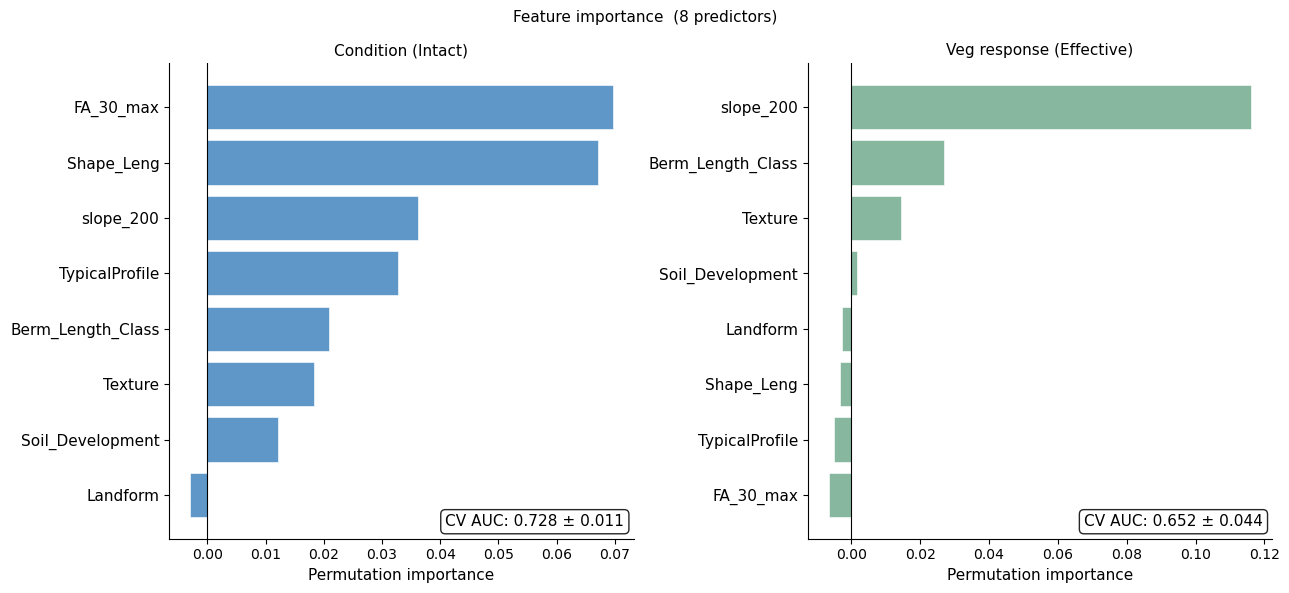

In [7]:
# ── Visualize RF feature importance ─────────────────────────────────────────
_N_FEAT = 8

def _single_target_panel(ax, importance_series, target_label, color, metrics):
    """Horizontal bar chart for one target's feature importance."""
    imp = importance_series.head(_N_FEAT)
    y = np.arange(len(imp))

    ax.barh(y, imp.values, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(imp.index, fontsize=FS)
    ax.invert_yaxis()
    ax.set_xlabel('Permutation importance', fontsize=FS)
    ax.set_title(target_label, fontsize=FS, fontweight='normal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    auc = metrics["cv"]["auc"]
    ax.text(0.98, 0.02, f"CV AUC: {auc[0]:.3f} ± {auc[1]:.3f}",
            transform=ax.transAxes, ha='right', va='bottom', fontsize=FS,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))


_fig_dir = os.path.join('..', 'figures', 'outcomes')
os.makedirs(_fig_dir, exist_ok=True)

auc_full_int = results_full["Intact"]["metrics"]["cv"]["auc"][0]
auc_full_eff = results_full["Effective"]["metrics"]["cv"]["auc"][0]
n_full = len(results_full["Intact"]["predictors"])

# ── Feature importance figure ────────────────────────────────────────────────
fig_full, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig_full.suptitle(f"Feature importance  ({n_full} predictors)",
                  fontsize=FS, fontweight='normal')

_single_target_panel(ax1, results_full["Intact"]["importance"],
                     "Condition (Intact)", MODEL_CLR_CONDITION,
                     results_full["Intact"]["metrics"])
_single_target_panel(ax2, results_full["Effective"]["importance"],
                     "Veg response (Effective)", MODEL_CLR_VEGRESPONSE,
                     results_full["Effective"]["metrics"])

plt.tight_layout()
_fig_name_full = 'fig_rf_full_importance.png'
fig_full.savefig(os.path.join(_fig_dir, _fig_name_full), dpi=300, bbox_inches='tight')

register_outcomes_figure(
    'fig_rf_full_importance',
    'RF — feature importance',
    _fig_name_full,
    f"""Random forest model ({n_full} predictors) feature importance for Condition (Intact) and Veg response (Effective) outcomes side by side.
Condition CV AUC = {auc_full_int:.3f}; top predictors: {', '.join(results_full['Intact']['importance'].head(3).index.tolist())}.
Veg response CV AUC = {auc_full_eff:.3f}; top predictors: {', '.join(results_full['Effective']['importance'].head(3).index.tolist())}.
Negative importances indicate features that add no signal beyond correlated predictors (effectively zero importance).""",
    f"""RF ({n_full} predictors) permutation importance: Condition CV AUC {auc_full_int:.3f}, Veg response CV AUC {auc_full_eff:.3f}. FA_30_max and Shape_Leng dominate for Condition; slope_200 dominates for Veg response."""
)
print(f"Saved: {_fig_name_full}")
plt.show()

Computing drop-column importances (fits 2 × 8 models) …
Done.


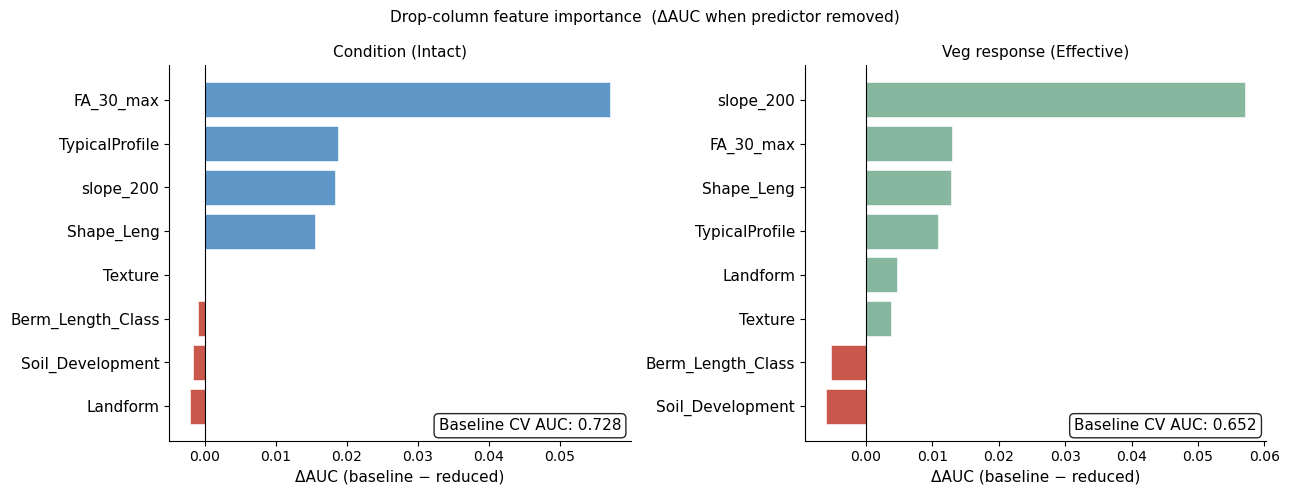

In [8]:
# ── Drop-column feature importances ─────────────────────────────────────────
# For each predictor: refit the full model with that column dropped, measure
# the decrease in CV AUC vs the baseline. More robust to correlated features
# than permutation importance.

_FS = FS

def _drop_col_importance(df, y_col, predictors, treat_as, baseline_auc):
    """Return a Series of AUC drops when each predictor is removed."""
    rows = {}
    for drop_p in predictors:
        reduced = [p for p in predictors if p != drop_p]
        try:
            _, _m, _ = fit_rf_binary(df, y=y_col, predictors=reduced, treat_as=treat_as)
            reduced_auc = _m["cv"]["auc"][0]
        except Exception:
            reduced_auc = np.nan
        rows[drop_p] = baseline_auc - reduced_auc   # positive = useful predictor
    return pd.Series(rows).sort_values(ascending=False)

_baseline_int = results_full["Intact"]["metrics"]["cv"]["auc"][0]
_baseline_eff = results_full["Effective"]["metrics"]["cv"]["auc"][0]

print("Computing drop-column importances (fits 2 × 8 models) …")
_dc_int = _drop_col_importance(df, "Intact",    full_predictors, full_treat_as, _baseline_int)
_dc_eff = _drop_col_importance(df, "Effective", full_predictors, full_treat_as, _baseline_eff)
print("Done.")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig_dc, (ax_dc1, ax_dc2) = plt.subplots(1, 2, figsize=(13, 5))
fig_dc.suptitle("Drop-column feature importance  (ΔAUC when predictor removed)",
                fontsize=_FS, fontweight="normal")

for ax, dc, title, color, baseline in [
    (ax_dc1, _dc_int, "Condition (Intact)",       MODEL_CLR_CONDITION,   _baseline_int),
    (ax_dc2, _dc_eff, "Veg response (Effective)", MODEL_CLR_VEGRESPONSE, _baseline_eff),
]:
    y = np.arange(len(dc))
    bar_colors = [color if v >= 0 else "#c0392b" for v in dc.values]
    ax.barh(y, dc.values, color=bar_colors, alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(dc.index, fontsize=_FS)
    ax.invert_yaxis()
    ax.set_xlabel("ΔAUC (baseline − reduced)", fontsize=_FS)
    ax.set_title(title, fontsize=_FS, fontweight="normal")
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(0.98, 0.02, f"Baseline CV AUC: {baseline:.3f}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=_FS,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

plt.tight_layout()
plt.show()

In [9]:
# ── Feature selection via drop-column importance ─────────────────────────────
# Keep only predictors whose drop-column ΔAUC >= 0 (removing them doesn't help).

_dc_results = {"Intact": _dc_int, "Effective": _dc_eff}
_pruned_rows = []
results_pruned = {}

print(f"\n{'='*60}")
print(f"  Feature selection — drop-column importance")
print(f"{'='*60}")

for _target in ["Intact", "Effective"]:
    _dc = _dc_results[_target]
    _selected = [p for p in full_predictors if _dc.get(p, 0) >= 0]
    _dropped  = [p for p in full_predictors if p not in _selected]

    print(f"\n  ── {_target} ──")
    print(f"    Drop-column importances:")
    for _p in full_predictors:
        _v = _dc.get(_p, 0)
        _flag = "  ✗ DROP" if _v < 0 else ""
        print(f"      {_p:25s}  ΔAUC = {_v:+.4f}{_flag}")
    print(f"    Dropped (ΔAUC < 0): {_dropped if _dropped else '— none —'}")
    print(f"    Selected ({len(_selected)}):      {_selected}")

    if len(_selected) == 0:
        print("    ⚠  No predictors survived — skipping refit.")
        continue

    _m_pruned, _metrics_pruned, _imp_pruned = fit_rf_binary(
        df, y=_target, predictors=_selected, treat_as=full_treat_as
    )
    results_pruned[_target] = {
        "model": _m_pruned, "metrics": _metrics_pruned,
        "importance": _imp_pruned, "predictors": _selected
    }

    _auc_before = results_full[_target]["metrics"]["cv"]["auc"]
    _auc_after  = _metrics_pruned["cv"]["auc"]
    _delta      = _auc_after[0] - _auc_before[0]
    print(f"    CV AUC full model:    {_auc_before[0]:.3f} ± {_auc_before[1]:.3f}  ({len(full_predictors)} predictors)")
    print(f"    CV AUC pruned model:  {_auc_after[0]:.3f} ± {_auc_after[1]:.3f}  ({len(_selected)} predictors)")
    print(f"    Δ AUC: {_delta:+.3f}")

    _pruned_rows.append({
        "Target":           _target,
        "Selection":        "drop-column",
        "N_predictors_all": len(full_predictors),
        "N_predictors_sel": len(_selected),
        "Dropped":          ", ".join(_dropped) if _dropped else "—",
        "AUC_full":         round(_auc_before[0], 3),
        "AUC_pruned":       round(_auc_after[0],  3),
        "Delta_AUC":        round(_delta, 3),
    })

_sel_df = pd.DataFrame(_pruned_rows)
print()
display(_sel_df)

# save comparison CSV
_sel_csv = "../data/summary/rf_feature_selection_comparison.csv"
_sel_df.to_csv(_sel_csv, index=False)
print(f"Saved: {_sel_csv}")


  Feature selection — drop-column importance

  ── Intact ──
    Drop-column importances:
      Landform                   ΔAUC = -0.0021  ✗ DROP
      slope_200                  ΔAUC = +0.0183
      FA_30_max                  ΔAUC = +0.0570
      Texture                    ΔAUC = -0.0001  ✗ DROP
      Soil_Development           ΔAUC = -0.0017  ✗ DROP
      TypicalProfile             ΔAUC = +0.0187
      Shape_Leng                 ΔAUC = +0.0155
      Berm_Length_Class          ΔAUC = -0.0010  ✗ DROP
    Dropped (ΔAUC < 0): ['Landform', 'Texture', 'Soil_Development', 'Berm_Length_Class']
    Selected (4):      ['slope_200', 'FA_30_max', 'TypicalProfile', 'Shape_Leng']
    CV AUC full model:    0.728 ± 0.011  (8 predictors)
    CV AUC pruned model:  0.735 ± 0.015  (4 predictors)
    Δ AUC: +0.007

  ── Effective ──
    Drop-column importances:
      Landform                   ΔAUC = +0.0046
      slope_200                  ΔAUC = +0.0571
      FA_30_max                  ΔAUC = +0.0130


,Target,Selection,N_predictors_all,N_predictors_sel,Dropped,AUC_full,AUC_pruned,Delta_AUC
0,Intact,drop-column,8,4,"Landform, Texture, Soil_Development, Berm_Leng...",0.728,0.735,0.007
1,Effective,drop-column,8,6,"Soil_Development, Berm_Length_Class",0.652,0.660,0.009


Saved: ../data/summary/rf_feature_selection_comparison.csv


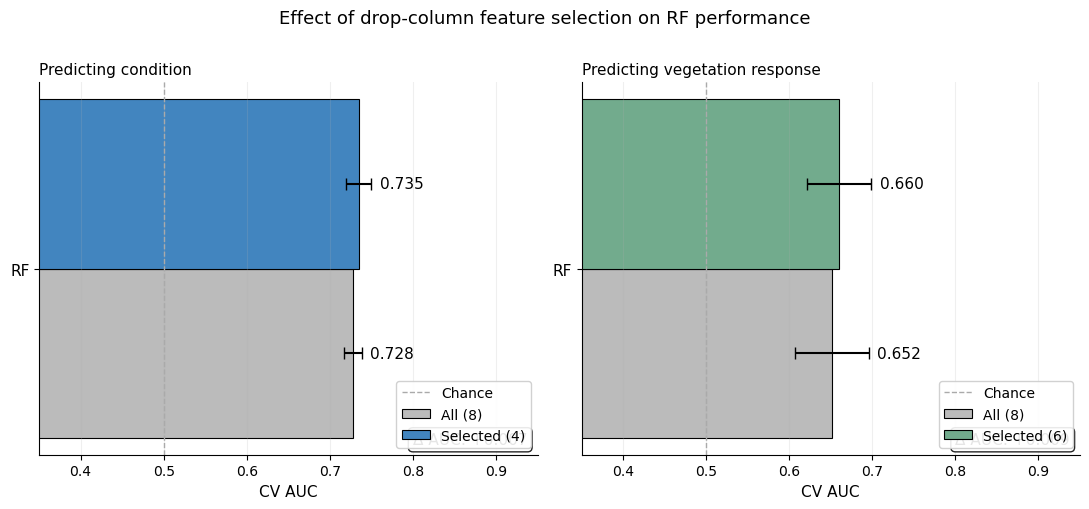

In [16]:
# ── Before vs After drop-column feature selection ─────────────────────────
_FS = FS
fig_sel, (ax_sel1, ax_sel2) = plt.subplots(1, 2, figsize=(11, 5), sharex=True)

for ax, _target, color in [
    (ax_sel1, 'Intact',    MODEL_CLR_CONDITION),
    (ax_sel2, 'Effective', MODEL_CLR_VEGRESPONSE),
]:
    _auc_before = results_full[_target]['metrics']['cv']['auc']
    _auc_after  = results_pruned[_target]['metrics']['cv']['auc']
    _n_all  = len(full_predictors)
    _n_sel  = len(results_pruned[_target]['predictors'])

    _y = np.array([0])
    _w = 0.32
    ax.barh(_y - _w/2, _auc_before[0], _w, xerr=_auc_before[1],
            color='#bbbbbb', edgecolor='black', lw=0.8, capsize=4,
            label=f'All ({_n_all})')
    ax.barh(_y + _w/2, _auc_after[0], _w, xerr=_auc_after[1],
            color=color, edgecolor='black', lw=0.8, capsize=4,
            label=f'Selected ({_n_sel})')

    # value labels
    ax.text(_auc_before[0] + _auc_before[1] + 0.01, -_w/2,
            f'{_auc_before[0]:.3f}', ha='left', va='center', fontsize=_FS)
    ax.text(_auc_after[0] + _auc_after[1] + 0.01, _w/2,
            f'{_auc_after[0]:.3f}', ha='left', va='center', fontsize=_FS)

    _delta = _auc_after[0] - _auc_before[0]
    ax.text(0.98, 0.02, f'Δ AUC: {_delta:+.3f}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=_FS,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

    ax.axvline(0.5, color=MODEL_CLR_CHANCE, ls='--', lw=1, label='Chance')
    ax.set_yticks([0])
    ax.set_yticklabels(['RF'], fontsize=_FS)
    ax.set_xlabel('CV AUC', fontsize=_FS)
    ax.set_xlim(0.35, 0.95)
    _tgt_label = 'condition' if _target == 'Intact' else 'vegetation response'
    ax.set_title(f'Predicting {_tgt_label}', fontsize=_FS, fontweight='normal', loc='left')
    ax.legend(fontsize=_FS - 1, loc='lower right', framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', alpha=0.2)

fig_sel.suptitle('Effect of drop-column feature selection on RF performance',
                 fontsize=FS_SUP, fontweight='normal', y=1.01)
plt.tight_layout()
plt.show()


In [10]:

# ---- Extra scenarios: effect_percent predicting Intact; Intact predicting Effective ----
base_all = scenario_predictors["all_predictors"]
extra_effective_runs = []

if "effect_percent" in df.columns:
    extra_effective_runs.append((
        "all_predictors + effect_percent", "Intact",
        _unique_preserve(base_all + ["effect_percent"])
    ))

if "Intact" in df.columns:
    extra_effective_runs.append((
        "all_predictors + Intact", "Effective",
        _unique_preserve(base_all + ["Intact"])
    ))

# Run extra scenarios and append to summary_rows
extra_log_lines = []
for scenario_name, target, predictors_run in extra_effective_runs:
    extra_log_lines.append(f"\n\n######## Extra: {scenario_name} / {target} ########")
    extra_log_lines.append(f"Predictors: {predictors_run}")
    try:
        model, metrics, pi = fit_rf_binary(df, y=target, predictors=predictors_run, treat_as=treat_as)
    except Exception as e:
        print(f"Skipping '{scenario_name}' / {target}: {e}")
        continue

    top3_str = ", ".join(pi.head(min(3, len(pi))).index.tolist())
    extra_log_lines.append(f"  cv_auc = {metrics['cv'].get('auc',(np.nan,np.nan))[0]:.4f}  top3 = {top3_str}")

    summary_rows.append({
        "scenario": scenario_name,
        "target": target,
        "cv_auc_mean": metrics["cv"].get("auc", (np.nan, np.nan))[0],
        "top_3_predictors": top3_str,
        "n": metrics["n"],
        "n_predictors": len(predictors_run),
        "cv_auc_sd": metrics["cv"].get("auc", (np.nan, np.nan))[1],
        "holdout_auc": metrics["holdout"].get("auc", np.nan),
        "cv_bal_acc_mean": metrics["cv"].get("bal_acc", (np.nan, np.nan))[0],
        "cv_f1_mean": metrics["cv"].get("f1", (np.nan, np.nan))[0],
    })

# Append extra log to file
results_txt = "../data/summary/scenario_model_results.txt"
with open(results_txt, "a") as f:
    f.write("\n".join(extra_log_lines))

# ---- Rebuild summary tables with reordered columns ----
col_order = [
    "scenario", "target", "cv_auc_mean", "top_3_predictors",
    "n", "n_predictors", "cv_auc_sd", "holdout_auc",
    "cv_bal_acc_mean", "cv_f1_mean",
]

scenario_summary = pd.DataFrame(summary_rows)

# Save to CSV so other notebooks can load it without re-running the RF fits
scenario_summary.to_csv("../data/summary/scenario_summary.csv", index=False)
print("Saved scenario_summary to ../data/summary/scenario_summary.csv")

# Save to CSV so other notebooks can load it without re-running the RF fits
scenario_summary.to_csv("../data/summary/scenario_summary.csv", index=False)
print("Saved scenario_summary to ../data/summary/scenario_summary.csv")
col_order = [c for c in col_order if c in scenario_summary.columns]

scenario_summary_effective = (
    scenario_summary.query("target == 'Effective'")[col_order]
    .sort_values("cv_auc_mean", ascending=False)
    .reset_index(drop=True)
)
scenario_summary_intact = (
    scenario_summary.query("target == 'Intact'")[col_order]
    .sort_values("cv_auc_mean", ascending=False)
    .reset_index(drop=True)
)

print("\n--- Effective ---")
display(scenario_summary_effective)
print("\n--- Intact ---")
display(scenario_summary_intact)


Saved scenario_summary to ../data/summary/scenario_summary.csv
Saved scenario_summary to ../data/summary/scenario_summary.csv

--- Effective ---


,scenario,target,cv_auc_mean,top_3_predictors,n,n_predictors,cv_auc_sd,holdout_auc,cv_bal_acc_mean,cv_f1_mean
0,all_predictors,Effective,0.651622,"slope_200, Berm_Length_Class, Texture",743,8,0.044287,0.645988,0.609234,0.581872
1,all_predictors + Intact,Effective,0.648915,"slope_200, Berm_Length_Class, Soil_Development",743,9,0.036397,0.649467,0.610157,0.580234
2,landscape_geomorphology_only,Effective,0.611596,"slope_200, Landform, FA_30_max",743,3,0.043316,0.680311,0.590170,0.570808
3,soil_only,Effective,0.578677,"TypicalProfile, Texture, Soil_Development",743,3,0.029888,0.621347,0.576589,0.542210
4,shape_length_only,Effective,0.558427,"Berm_Length_Class, Shape_Leng",743,2,0.036279,0.497449,0.532750,0.498728



--- Intact ---


,scenario,target,cv_auc_mean,top_3_predictors,n,n_predictors,cv_auc_sd,holdout_auc,cv_bal_acc_mean,cv_f1_mean
0,all_predictors,Intact,0.727806,"FA_30_max, Shape_Leng, slope_200",743,8,0.010714,0.771605,0.656144,0.707243
1,all_predictors + effect_percent,Intact,0.720881,"FA_30_max, Shape_Leng, slope_200",743,9,0.018664,0.770062,0.657340,0.715063
2,landscape_geomorphology_only,Intact,0.655780,"FA_30_max, slope_200, Landform",743,3,0.017483,0.679843,0.592318,0.668733
3,soil_only,Intact,0.627627,"TypicalProfile, Texture, Soil_Development",743,3,0.034388,0.618352,0.585442,0.695597
4,shape_length_only,Intact,0.564382,"Shape_Leng, Berm_Length_Class",743,2,0.017848,0.640966,0.541896,0.620880


In [11]:
# Quick baseline CV AUC for both targets using all_predictors
_preds_quick = scenario_predictors["all_predictors"]
_, _met_int, _ = fit_rf_binary(df, y="Intact",    predictors=_preds_quick, treat_as=treat_as)
_, _met_eff, _ = fit_rf_binary(df, y="Effective", predictors=_preds_quick, treat_as=treat_as)

_auc_int = _met_int["cv"]["auc"]   # (mean, sd)
_auc_eff = _met_eff["cv"]["auc"]

print(f"Condition    CV AUC: {_auc_int[0]:.3f} ± {_auc_int[1]:.3f}  (n={_met_int['n']})")
print(f"Veg response CV AUC: {_auc_eff[0]:.3f} ± {_auc_eff[1]:.3f}  (n={_met_eff['n']})")

Condition    CV AUC: 0.728 ± 0.011  (n=743)
Veg response CV AUC: 0.652 ± 0.044  (n=743)



## Predictor scenarios

Random forest models were fitted for two binary outcomes — **Intactness** (intact vs. degraded) and **Effectiveness** (effective vs. ineffective) — using four predictor scenarios representing each conceptually distinct predictor group individually and all groups combined:

| Scenario | Predictors included |
|---|---|
| **Geomorphology only** | Landform class, hillslope gradient (slope_200), flow accumulation (FA_30_max) |
| **Soil only** | Soil texture class, soil development, parent material, % clay / sand / silt (r-horizon and surface) |
| **Shape length only** | Berm shape length (Shape_Leng) |
| **All predictors** | All three groups combined |

Model performance is reported as mean cross-validated ROC-AUC (± SD, 5-fold stratified CV). All models use a balanced random forest (class_weight="balanced", 300 trees).

In [12]:
# ── Load scenario_summary from RF notebook output ──────────────────────────────
import os
_ss_path = '../data/summary/scenario_summary.csv'
if os.path.exists(_ss_path):
    scenario_summary = pd.read_csv(_ss_path)
    print(f'Loaded scenario_summary: {len(scenario_summary)} rows, targets={scenario_summary["target"].unique().tolist()}')
else:
    print(f'WARNING: {_ss_path} not found — run models - rf approaches.ipynb first to generate it.')
    scenario_summary = None


Loaded scenario_summary: 10 rows, targets=['Intact', 'Effective']


In [13]:
import sys as _sys
_sys.path.insert(0, '../src')
from constants import (
    INTACT_COL, DEGRADED_COL, BREACH_COL, FLANK_COL,
    LF_COLORS, lf_order,
    LENGTH_COLORS, length_order,
    SLOPE_COLORS, slope_order,
    CLAY_COLORS, clay_order,
    SOILDEV_COLORS, soildev_order,
    TEXTURE_COLORS, texture_order,
    LBL_EFFECTIVE, LBL_INEFFECTIVE, eff_order, eff_colors,
    fail_order, fail_colors,
    MODEL_CLR_CONDITION, MODEL_CLR_VEGRESPONSE, MODEL_CLR_CHANCE,
)

# ── colour palette (canonical model-outcome colours from constants) ───────────
CLR_INTACT  = MODEL_CLR_CONDITION    # blue       – Condition model
CLR_EFF     = MODEL_CLR_VEGRESPONSE  # sage green – Vegetation response model
CLR_CHANCE  = MODEL_CLR_CHANCE       # grey dashed chance line


Saved → ../figures/geomorph_soil_intact_effective.png


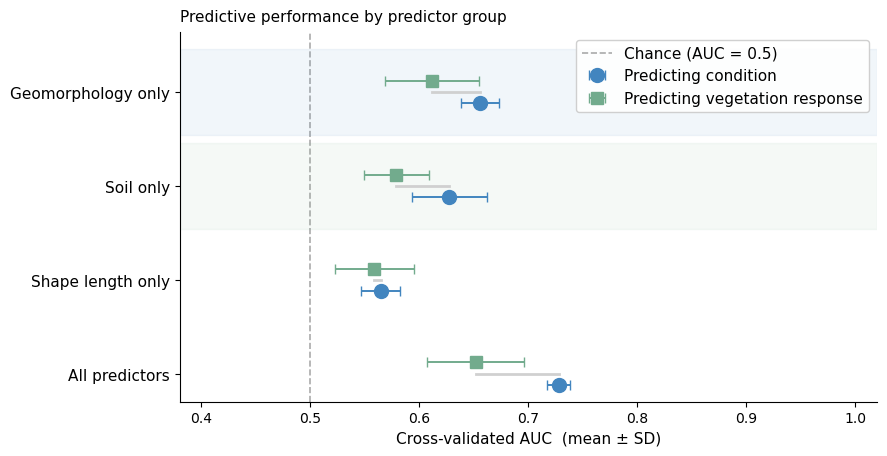

In [14]:

# ── Panel A data: four key predictor-group scenarios ─────────────────────────
key_order   = ["landscape_geomorphology_only", "soil_only",
               "shape_length_only", "all_predictors"]
label_map   = {
    "landscape_geomorphology_only": "Geomorphology only",
    "soil_only":                    "Soil only",
    "shape_length_only":            "Shape length only",
    "all_predictors":               "All predictors",
}

sub_ss = (
    scenario_summary[scenario_summary["scenario"].isin(key_order)]
    [["scenario", "target", "cv_auc_mean", "cv_auc_sd"]].copy()
)
sub_ss["label"] = sub_ss["scenario"].map(label_map)
sub_ss["order"] = sub_ss["scenario"].map({s: i for i, s in enumerate(key_order)})

pivoted = (
    sub_ss.pivot_table(index=["scenario", "label", "order"],
                       columns="target",
                       values=["cv_auc_mean", "cv_auc_sd"])
    .reset_index()
    .sort_values("order")
)

y_pos        = np.arange(len(pivoted))
labels_y     = pivoted["label"].tolist()
scenarios_y  = pivoted["scenario"].tolist()
intact_auc   = pivoted[("cv_auc_mean", "Intact")].values
intact_sd    = pivoted[("cv_auc_sd",   "Intact")].values
eff_auc      = pivoted[("cv_auc_mean", "Effective")].values
eff_sd       = pivoted[("cv_auc_sd",   "Effective")].values

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 4.8))

# ── Paired dot plot ───────────────────────────────────────────────────────────
for yi, ia, ea in zip(y_pos, intact_auc, eff_auc):
    ax1.plot([ia, ea], [yi, yi], color="#d0d0d0", linewidth=2, zorder=1)

ax1.errorbar(intact_auc, y_pos + 0.12, xerr=intact_sd,
             fmt="o", color=CLR_INTACT, markersize=10,
             elinewidth=1.4, capsize=3.5, label="Predicting condition", zorder=3)
ax1.errorbar(eff_auc, y_pos - 0.12, xerr=eff_sd,
             fmt="s", color=CLR_EFF, markersize=9,
             elinewidth=1.4, capsize=3.5, label="Predicting vegetation response", zorder=3)

ax1.axvline(0.5, color=CLR_CHANCE, linestyle="--", linewidth=1.2,
            label="Chance (AUC = 0.5)", zorder=0)

# Subtle row shading for the two "signature" scenarios
for yi, sname in zip(y_pos, scenarios_y):
    if sname == "landscape_geomorphology_only":
        ax1.axhspan(yi - 0.46, yi + 0.46, alpha=0.07, color=CLR_INTACT, zorder=0)
    elif sname == "soil_only":
        ax1.axhspan(yi - 0.46, yi + 0.46, alpha=0.07, color=CLR_EFF, zorder=0)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels_y, fontsize=FS)
ax1.invert_yaxis()
ax1.set_xlim(0.38, 1.02)
ax1.set_xlabel("Cross-validated AUC  (mean ± SD)", fontsize=FS)
ax1.set_title("Predictive performance by predictor group",
              fontsize=FS, fontweight="normal", loc="left", pad=8)
ax1.legend(loc="upper right", fontsize=FS, framealpha=0.92)
ax1.spines[["top", "right"]].set_visible(False)

os.makedirs("../figures", exist_ok=True)
out_path = "../figures/geomorph_soil_intact_effective.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()